# Titanic Classification with PyTorch

X_train size:  3983  Y_train size:  569  x_test:  1001
Epoch 1, Loss: 12.6353, Test Accuracy: 0.5385
Epoch 2, Loss: 12.3808, Test Accuracy: 0.5594
Epoch 3, Loss: 12.3020, Test Accuracy: 0.5664
Epoch 4, Loss: 12.1139, Test Accuracy: 0.5734
Epoch 5, Loss: 11.9206, Test Accuracy: 0.6014
Epoch 6, Loss: 11.7740, Test Accuracy: 0.6503
Epoch 7, Loss: 11.5758, Test Accuracy: 0.7203
Epoch 8, Loss: 11.2697, Test Accuracy: 0.7203
Epoch 9, Loss: 11.1368, Test Accuracy: 0.7413
Epoch 10, Loss: 10.7235, Test Accuracy: 0.7762
Epoch 11, Loss: 10.5251, Test Accuracy: 0.7902
Epoch 12, Loss: 10.1429, Test Accuracy: 0.7972
Epoch 13, Loss: 10.0409, Test Accuracy: 0.8042
Epoch 14, Loss: 9.6564, Test Accuracy: 0.8042
Epoch 15, Loss: 9.7142, Test Accuracy: 0.8042
Epoch 16, Loss: 9.3244, Test Accuracy: 0.8042
Epoch 17, Loss: 9.2398, Test Accuracy: 0.8042
Epoch 18, Loss: 8.9767, Test Accuracy: 0.7972
Epoch 19, Loss: 8.9818, Test Accuracy: 0.8042
Epoch 20, Loss: 9.2083, Test Accuracy: 0.7972
Epoch 21, Loss: 8.821

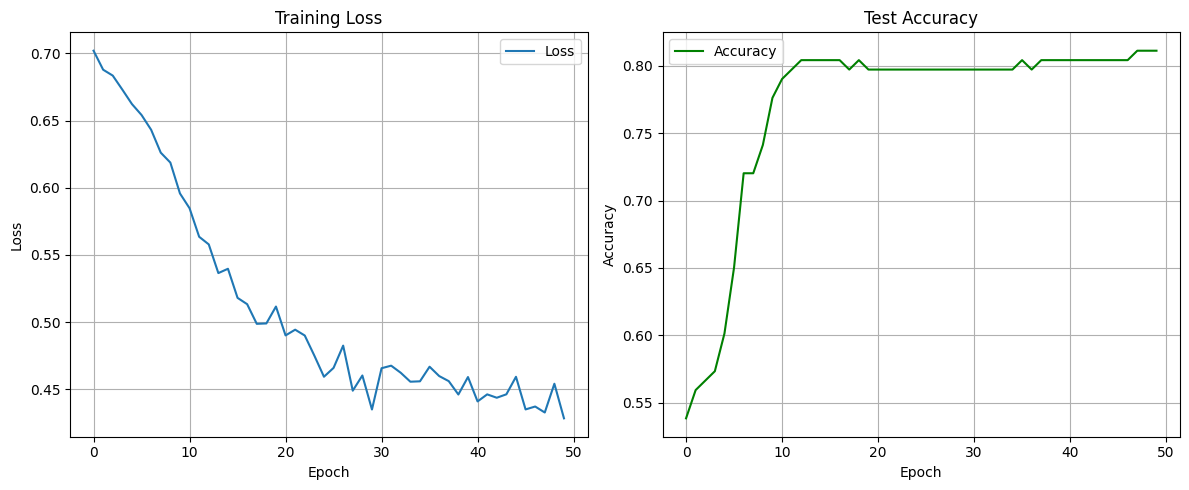

In [11]:

# Titanic Survival Prediction with PyTorch

## 1. Imports and Data Loading
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch import nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("titanic.csv")

## 2. Preprocessing
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
df.dropna(inplace=True)

# Encode categorical features
df['Sex'] = LabelEncoder().fit_transform(df['Sex'])
df['Embarked'] = LabelEncoder().fit_transform(df['Embarked'])

# Split into features and label
X = df.drop('Survived', axis=1).values
y = df['Survived'].values


# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train size: " , X_train.size , " Y_train size: "  , y_train.size , " x_test: " , X_test.size );

## 3. PyTorch Dataset
class TitanicDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TitanicDataset(X_train, y_train)
test_dataset = TitanicDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

## 4. Model Definition
# class TitanicModel(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.fc1 = nn.Linear(7, 14)
#         self.fc2 = nn.Linear(14, 8)
#         self.output = nn.Linear(8, 1)
#         self.Dropout = nn.Dropout(0.2)

#     def forward(self, x):
#         x = F.relu(self.fc1(x))
#         x = F.relu(self.fc2(x))
#         return torch.sigmoid(self.output(x))
class ImprovedModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(7, 14),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(14, 7),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(7, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

# model = TitanicModel()
model = ImprovedModel()

## 5. Training
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

train_losses = []
test_accuracies = []

for epoch in range(50):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))

    # Evaluation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            preds = model(X_batch)
            predicted = (preds > 0.5).float()
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
    accuracy = correct / total
    test_accuracies.append(accuracy)
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Test Accuracy: {accuracy:.4f}")

## 6. Plotting Results
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
plt.plot(test_accuracies, label='Accuracy', color='green')
plt.title('Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


## 🔍 Confusion Matrix and Hyperparameter Tuning

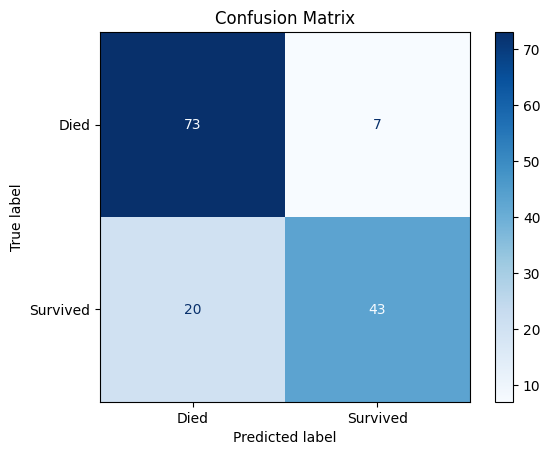

In [12]:

## 7. Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Collect all predictions and true labels
y_true = []
y_pred = []
model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch)
        predicted = (preds > 0.5).int().numpy()
        y_true.extend(y_batch.numpy().astype(int).flatten())
        y_pred.extend(predicted.flatten())

# Display confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Died", "Survived"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()
